In [7]:
import pandas as pd 
data1 = pd.read_csv('house-prices-advanced-regression-techniques/sample_submission.csv')
data2 = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')
data3 = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

In [13]:
print(data1.head())
print(data2.head())
print(data3.head())

     Id      SalePrice
0  1461  169277.052498
1  1462  187758.393989
2  1463  183583.683570
3  1464  179317.477511
4  1465  150730.079977
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         

# Data1 visualizing and understanding  

In [30]:
print(data1.describe())
print(data1.columns)

                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  179183.918243
std     421.321334   16518.303051
min    1461.000000  135751.318893
25%    1825.500000  168703.011202
50%    2190.000000  179208.665698
75%    2554.500000  186789.409363
max    2919.000000  281643.976117
Index(['Id', 'SalePrice'], dtype='object')


Text(0.5, 1.0, 'SalePrice vs IDs')

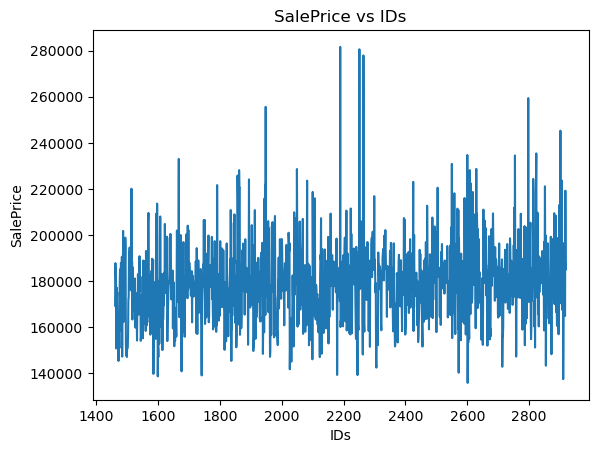

In [40]:
import matplotlib.pyplot as plt 
plt.plot(data1['Id'] , data1['SalePrice'])
plt.xlabel("IDs" ) 
plt.ylabel("SalePrice")
plt.title("SalePrice vs IDs")

# Important Note

The provided dataset is considered primary data and must not be altered or modified. All analysis should be performed on copies of the data or through non-destructive operations that preserve the integrity of the original dataset.

# Data2 visualizing and understanding 

In [57]:
print(data2.describe())
print(data2.columns)
print(data2.head()) 

                Id   MSSubClass  LotFrontage       LotArea  OverallQual  \
count  1459.000000  1459.000000  1232.000000   1459.000000  1459.000000   
mean   2190.000000    57.378341    68.580357   9819.161069     6.078821   
std     421.321334    42.746880    22.376841   4955.517327     1.436812   
min    1461.000000    20.000000    21.000000   1470.000000     1.000000   
25%    1825.500000    20.000000    58.000000   7391.000000     5.000000   
50%    2190.000000    50.000000    67.000000   9399.000000     6.000000   
75%    2554.500000    70.000000    80.000000  11517.500000     7.000000   
max    2919.000000   190.000000   200.000000  56600.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1459.000000  1459.000000   1459.000000  1444.000000  1458.000000  ...   
mean      5.553804  1971.357779   1983.662783   100.709141   439.203704  ...   
std       1.113740    30.390071     21.130467   177.625900   455.268042  ...   
min 

In [77]:
nullcal =data2.isnull().sum()
print(nullcal,end=("*"*100)+"\n")
col = nullcal[nullcal>0]
print(col)

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64****************************************************************************************************
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence         

In [79]:
import seaborn as sns

<Axes: >

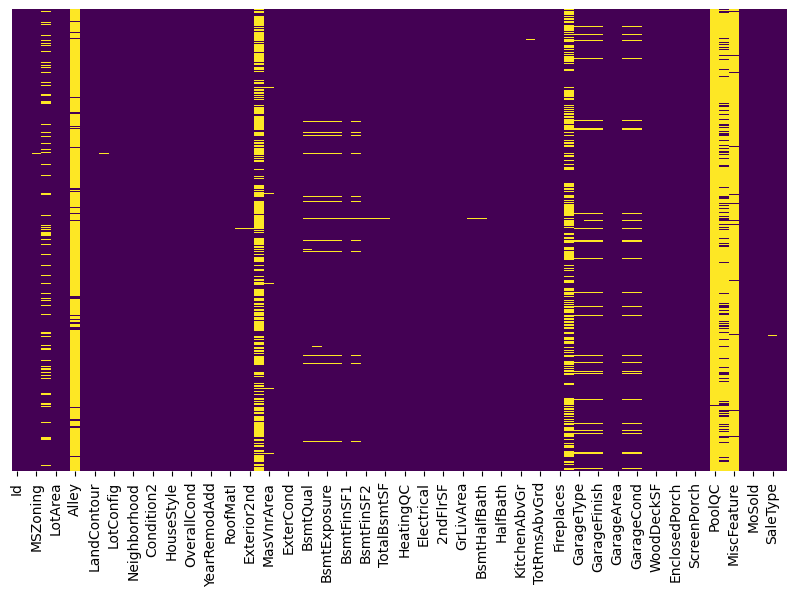

In [155]:
import numpy as np
plt.figure(figsize=(10,6))
sns.heatmap(data2.isnull(),cbar=False, cmap='viridis',yticklabels=False )

In [179]:
from sklearn.tree import DecisionTreeClassifier

In [183]:
def split_dataset(dataset, test_ratio=0.30):
  test_indices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(data3)
print("{} examples in training, {} examples in testing.".format(
    len(train_ds_pd), len(valid_ds_pd)))


1027 examples in training, 433 examples in testing.
